# 07 · Paradigm war — heterogeneity-driven shock dynamics (v2)

Notebook 06 ran the v2 model end-to-end on a homogeneous population and showed
the *qualitative* paradigm-persistence story (μ̄ lags, τ̄ grows). What it did
*not* show is anything that looks like a paradigm shift in the Kuhnian sense:
no factions, no contested period, no hysteresis loop. Three reasons:

1. **Everyone starts at the same prior** (μ=0, τ=1). With identical agents on
   a symmetric graph, the social pool degenerates to a uniform neighbour
   average — trust never differentiates because every q_j is roughly equal.
2. **`pop.gamma` is row-normalised every step.** The Gamma-conjugate machinery
   *is* learning (α, β diverge), but the publicly-displayed γ is a row-
   stochastic pooling weight that stays pinned near 1/(degree+1). Diagnostic
   plots should show raw α/β, not γ.
3. **The schedule is a one-way step.** Hysteresis needs the world to *return*
   to the pre-shock paradigm so we can test whether the community can come
   back. The `schedule='reversal'` branch already exists in `src/world.py` —
   we just need to use it.

This notebook:

- **§0** Re-runs 06's setup but plots raw α/β alongside γ to confirm trust
  *is* learning.
- **§1** Builds a **two-faction** population — half Newtonian-prior (μ=0,
  τ=τ₀), half relativistic-prior (μ=1, τ=τ₀) — and watches the trust matrix
  re-allocate as the truth flips.
- **§2** Same population but on a **reversal** schedule. Plots the phase
  portrait `(θ*(t), ⟨μ⟩_faction(t))` per faction. Loop area = hysteresis.
- **§3** Stub for the 2×2 (Γ-learning × Bayesian rigidity) decomposition that
  IWAI E1 wants. Filled in by notebook 08.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    build, ModelConfig, WorldConfig, PolicyConfig, TrustConfig, NetworkConfig,
    History, Population,
)

sns.set_theme(context='notebook', style='whitegrid')
np.set_printoptions(precision=3, suppress=True)
print('imports ok')

imports ok


## §0 · Diagnostic — what 06 *actually* showed

Replay the 06 setup but track three things 06 didn't plot:

- **raw α and β** (not γ) — the *unnormalised* trust state. If learning is
  on, these grow without bound; their *ratio* α/β is the precision the agent
  attaches to each neighbour.
- **between-row variance of α/β** — heterogeneity across rows of the trust
  matrix. If everyone trusts everyone the same amount, this is zero. The
  bigger it is, the more the social pool is doing something non-trivial.
- **per-agent μ trajectories** (small-multiples) — to confirm the population
  really is moving in lockstep (or not).

In [2]:
def rollout(pop, T, snap_every=2):
    """Run T steps; return (pop, hist, thetas_arr)."""
    hist = History()
    thetas = []
    hist.snap(pop, every=snap_every)
    for t in range(T):
        pop, out = pop.step(t)
        thetas.append(out['theta_star'])
        hist.snap(pop, every=snap_every)
    return pop, hist, np.array(thetas)


def snaps_to_arrays(hist):
    """Stack snapshot dicts into (T_snap, ...) arrays for plotting."""
    s = hist.as_snapshots()
    return dict(
        step=np.array([r['step'] for r in s]),
        mu=np.stack([r['mu'] for r in s]),
        tau=np.stack([r['tau'] for r in s]),
        gamma=np.stack([r['gamma'] for r in s]),
        alpha=np.stack([r['alpha'] for r in s]),
        beta=np.stack([r['beta'] for r in s]),
    )


cfg06 = ModelConfig(
    n_agents=60, mu_0=0.0, tau_0=1.0, seed=0,
    world=WorldConfig(theta_star_pre=0.0, theta_star_post=1.0,
                      schedule='step', schedule_t_shift=30),
)
pop06 = build(cfg06)
pop06, hist06, thetas06 = rollout(pop06, T=200, snap_every=2)
arr06 = snaps_to_arrays(hist06)
print(f'final: {pop06!r}')
print(f"mu spread (std across agents) at end = {arr06['mu'][-1].std():.3f}")

final: Population(N=60, edges=120, mu_mean=+0.725, tau_mean=195.883, gamma_mean=0.2000)
mu spread (std across agents) at end = 0.007


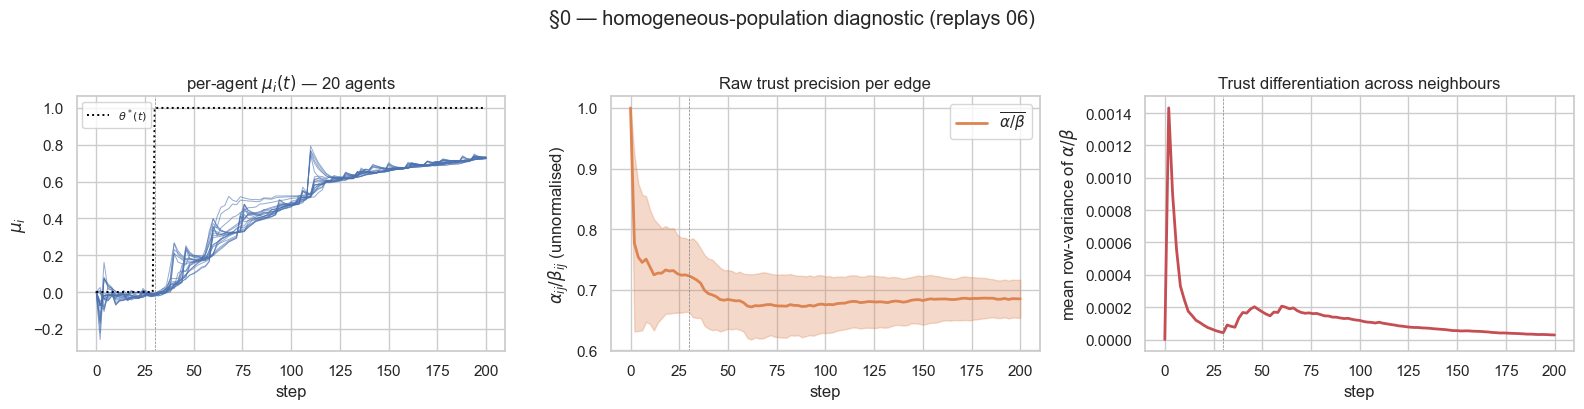

In [3]:
def trust_diagnostics(arr, A_self_adj, title='diagnostic'):
    """Three-panel diagnostic: (i) mu_i(t) per-agent strip, (ii) raw alpha/beta
    edge-mean and edge-std over time, (iii) row-variance of alpha/beta."""
    mask = np.asarray(A_self_adj) > 0
    alpha_t, beta_t = arr['alpha'], arr['beta']
    ratio_t = alpha_t / (beta_t + 1e-12)            # (T_snap, N, N)
    step = arr['step']

    edge_mean = np.array([r[mask].mean() for r in ratio_t])
    edge_std = np.array([r[mask].std() for r in ratio_t])

    # Row variance: how much does i's trust differ across its neighbours?
    # For each row, variance over the masked entries; then average over rows.
    def row_var(R):
        rv = []
        for i in range(R.shape[0]):
            row = R[i][mask[i]]
            if row.size > 1:
                rv.append(row.var())
        return float(np.mean(rv)) if rv else 0.0

    row_var_t = np.array([row_var(r) for r in ratio_t])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    # (i) per-agent mu trajectories — small subset for clarity
    n_show = min(20, arr['mu'].shape[1])
    for i in range(n_show):
        axes[0].plot(step, arr['mu'][:, i], lw=0.7, alpha=0.6, color='C0')
    axes[0].plot(np.arange(len(thetas06)), thetas06, color='black', ls=':', lw=1.4,
                 label=r'$\theta^*(t)$')
    axes[0].axvline(cfg06.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
    axes[0].set(xlabel='step', ylabel=r'$\mu_i$',
                title=f'per-agent $\\mu_i(t)$ — {n_show} agents')
    axes[0].legend(fontsize=8)

    # (ii) raw alpha/beta edge mean +/- std
    axes[1].fill_between(step, edge_mean - edge_std, edge_mean + edge_std,
                          alpha=0.3, color='C1')
    axes[1].plot(step, edge_mean, color='C1', lw=2, label=r'$\overline{\alpha/\beta}$')
    axes[1].axvline(cfg06.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
    axes[1].set(xlabel='step', ylabel=r'$\alpha_{ij}/\beta_{ij}$ (unnormalised)',
                title='Raw trust precision per edge')
    axes[1].legend()

    # (iii) row-variance
    axes[2].plot(step, row_var_t, color='C3', lw=2)
    axes[2].axvline(cfg06.world.schedule_t_shift, color='grey', ls='--', lw=0.5)
    axes[2].set(xlabel='step', ylabel='mean row-variance of $\\alpha/\\beta$',
                title='Trust differentiation across neighbours')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig


trust_diagnostics(arr06, pop06.A_self_adj, title='§0 — homogeneous-population diagnostic (replays 06)')
plt.show()

## §1 · Paradigm war — two factions, step shock

Split the N=80 population into two factions:

- **Newtonians** (faction 0): start at μ=0, τ=τ₀. They are *right* during the
  pre-shock phase.
- **Relativists** (faction 1): start at μ=1, τ=τ₀. They are *wrong* during
  the pre-shock phase but *right* after the shock.

Both factions share the same τ₀ so the contrast is purely about prior mean,
not certainty. The graph is an SBM with `intra_prob > inter_prob` so the
factions form modular blocks — within-faction social pooling reinforces
each prior, between-faction edges are the dispute channel.

What to look for after the t=50 shock:

1. **μ̄_Newtonian rises** (they were calibrated to truth, now have to
   abandon it).
2. **μ̄_Relativist stays stable or sharpens** (they were vindicated).
3. **The Relativist→Newtonian trust column** in α/β grows fast around the
   shock (Newtonians find Relativists' predictions less surprising once
   θ*=1 is the truth).
4. **Newtonians' own self-trust α_ii/β_ii** drops (their predictive is now
   miscalibrated to the observations they generate).

In [4]:
def build_two_faction(cfg, mu_per_faction=(0.0, 1.0), tau_per_faction=(1.0, 1.0),
                       faction_fractions=(0.5, 0.5)):
    """Build a Population then override mu, tau per faction.

    Returns (pop, membership) where membership[i] ∈ {0, 1}.

    No src/ change needed — we just rewrite pop.mu and pop.tau via eqx.tree_at.
    The trust prior (alpha, beta) is left at the homogeneous initialisation so
    we can watch trust drift away from uniform as a *result* of the dynamics.
    """
    N = cfg.n_agents
    f0, f1 = faction_fractions
    assert abs(f0 + f1 - 1.0) < 1e-9, 'fractions must sum to 1'
    n0 = int(round(N * f0))
    membership = np.concatenate([np.zeros(n0, dtype=np.int32),
                                  np.ones(N - n0, dtype=np.int32)])

    pop = build(cfg)
    mu_init = jnp.where(jnp.asarray(membership) == 0,
                         mu_per_faction[0], mu_per_faction[1]).astype(jnp.float32)
    tau_init = jnp.where(jnp.asarray(membership) == 0,
                          tau_per_faction[0], tau_per_faction[1]).astype(jnp.float32)
    pop = eqx.tree_at(lambda p: (p.mu, p.tau), pop, (mu_init, tau_init))
    return pop, membership


def faction_means(arr, membership):
    """Return (mu_per_faction (T_snap, S), tau_per_faction (T_snap, S))."""
    S = int(membership.max() + 1)
    mu_t, tau_t = arr['mu'], arr['tau']
    mu_f = np.stack([mu_t[:, membership == s].mean(axis=1) for s in range(S)], axis=1)
    tau_f = np.stack([tau_t[:, membership == s].mean(axis=1) for s in range(S)], axis=1)
    return mu_f, tau_f


cfg_war = ModelConfig(
    n_agents=80, mu_0=0.0, tau_0=1.0, seed=1,
    world=WorldConfig(theta_star_pre=0.0, theta_star_post=1.0,
                      schedule='step', schedule_t_shift=50),
    network=NetworkConfig(kind='watts_strogatz', mean_degree=6, rewiring_p=0.1),
    trust=TrustConfig(rho=0.99, learning=True),
)
pop_war, membership = build_two_faction(cfg_war,
                                          mu_per_faction=(0.0, 1.0),
                                          tau_per_faction=(1.0, 1.0))
print(f'init: {pop_war!r}')
print(f'faction sizes: Newtonian={int((membership==0).sum())}, '
      f'Relativist={int((membership==1).sum())}')
print(f'mu range at init: [{float(pop_war.mu.min()):.2f}, {float(pop_war.mu.max()):.2f}]')

init: Population(N=80, edges=240, mu_mean=+0.500, tau_mean=1.000, gamma_mean=0.1429)
faction sizes: Newtonian=40, Relativist=40
mu range at init: [0.00, 1.00]


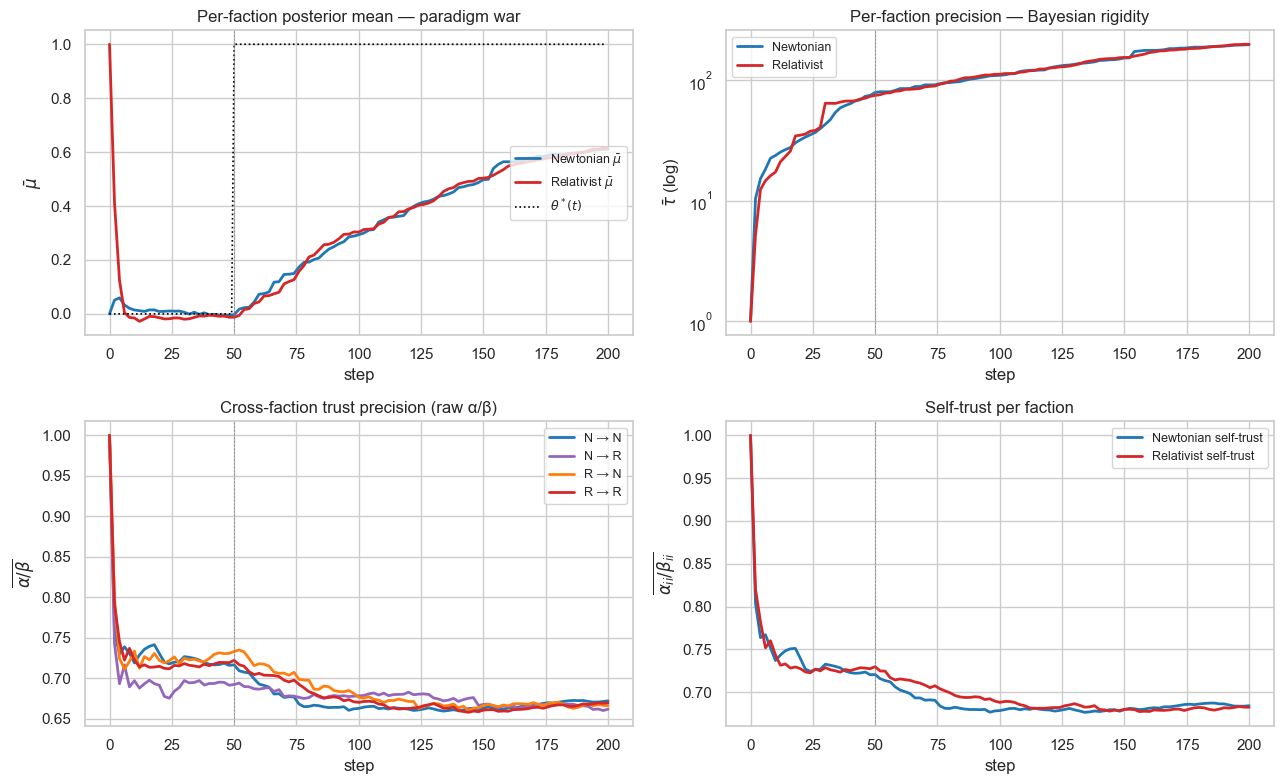

mu pre-shock  (t = 49): N = -0.005, R = -0.012
mu post-shock (t = end):       N = +0.611, R = +0.614


In [5]:
T_war = 200
pop_war_end, hist_war, thetas_war = rollout(pop_war, T=T_war, snap_every=2)
arr_war = snaps_to_arrays(hist_war)
mu_f, tau_f = faction_means(arr_war, membership)

t_shift = cfg_war.world.schedule_t_shift
step = arr_war['step']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (a) Per-faction mu trajectories
ax = axes[0, 0]
ax.plot(step, mu_f[:, 0], lw=2, color='#1f77b4', label=r'Newtonian $\bar\mu$')
ax.plot(step, mu_f[:, 1], lw=2, color='#d62728', label=r'Relativist $\bar\mu$')
ax.plot(np.arange(T_war), thetas_war, color='black', ls=':', lw=1.2, label=r'$\theta^*(t)$')
ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\bar\mu$',
       title='Per-faction posterior mean — paradigm war')
ax.legend(fontsize=9, loc='center right')

# (b) Per-faction tau (log)
ax = axes[0, 1]
ax.plot(step, tau_f[:, 0], lw=2, color='#1f77b4', label='Newtonian')
ax.plot(step, tau_f[:, 1], lw=2, color='#d62728', label='Relativist')
ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\bar\tau$ (log)', yscale='log',
       title='Per-faction precision — Bayesian rigidity')
ax.legend(fontsize=9)

# (c) Cross-faction trust: mean alpha/beta on the four block submatrices
mask = np.asarray(pop_war_end.A_self_adj) > 0
ratio_t = arr_war['alpha'] / (arr_war['beta'] + 1e-12)
blocks = {}
for src_s in (0, 1):
    for tgt_s in (0, 1):
        sel = (membership[:, None] == src_s) & (membership[None, :] == tgt_s) & mask
        vals = np.array([r[sel].mean() if sel.any() else np.nan for r in ratio_t])
        blocks[(src_s, tgt_s)] = vals
labels = {(0, 0): 'N → N', (0, 1): 'N → R', (1, 0): 'R → N', (1, 1): 'R → R'}
colors = {(0, 0): '#1f77b4', (0, 1): '#9467bd', (1, 0): '#ff7f0e', (1, 1): '#d62728'}
ax = axes[1, 0]
for k, v in blocks.items():
    ax.plot(step, v, lw=2, color=colors[k], label=labels[k])
ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\overline{\alpha/\beta}$',
       title='Cross-faction trust precision (raw α/β)')
ax.legend(fontsize=9)

# (d) Self-trust (diagonal of alpha/beta) per faction
ax = axes[1, 1]
diag_idx = np.arange(len(membership))
self_ratio = ratio_t[:, diag_idx, diag_idx]   # (T_snap, N)
self_f0 = self_ratio[:, membership == 0].mean(axis=1)
self_f1 = self_ratio[:, membership == 1].mean(axis=1)
ax.plot(step, self_f0, lw=2, color='#1f77b4', label='Newtonian self-trust')
ax.plot(step, self_f1, lw=2, color='#d62728', label='Relativist self-trust')
ax.axvline(t_shift, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\overline{\alpha_{ii}/\beta_{ii}}$',
       title='Self-trust per faction')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'mu pre-shock  (t = {t_shift - 1}): N = {mu_f[t_shift//2 - 1, 0]:+.3f}, '
      f'R = {mu_f[t_shift//2 - 1, 1]:+.3f}')
print(f'mu post-shock (t = end):       N = {mu_f[-1, 0]:+.3f}, '
      f'R = {mu_f[-1, 1]:+.3f}')

## §2 · Hysteresis under a reversal schedule

Now run the *same* two-faction setup but with the world running

  θ* = 0 for t ∈ [0, 50), θ* = 1 for t ∈ [50, 150), θ* = 0 for t ∈ [150, T)

The crisis comes back. If the model is doing what we hope, then *after the
reverse shock at t = 150 the Newtonians cannot snap back* — they spent 100
steps re-tuning to θ*=1 and accumulated precision around the new value. The
phase portrait `(θ*(t), ⟨μ⟩_faction(t))` should trace a closed loop with
nonzero area (= hysteresis), and the loop should be larger for the faction
with higher accumulated τ at the moment of the reverse shock.

We compute the loop area via the shoelace formula on the
`(θ*(t), ⟨μ⟩(t))` polyline.

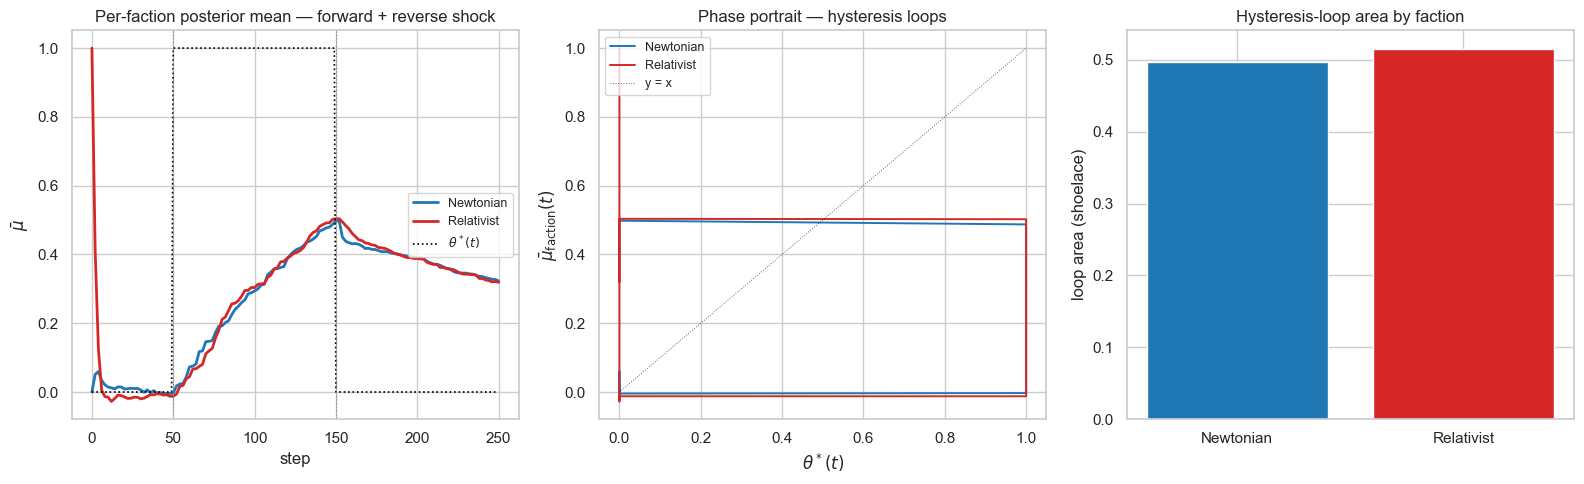

Newtonian loop area: 0.4965
Relativist loop area: 0.5154
tau at reverse-shock (t=150) — N: 153.54, R: 154.85
tau at run-end          — N: 234.11, R: 237.21


In [6]:
def shoelace_area(x, y):
    """Signed area of the closed polyline (x[k], y[k]). Sign indicates
    orientation; absolute value is the loop area."""
    x = np.asarray(x); y = np.asarray(y)
    return 0.5 * float(np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


cfg_rev = ModelConfig(
    n_agents=80, mu_0=0.0, tau_0=1.0, seed=1,
    world=WorldConfig(theta_star_pre=0.0, theta_star_post=1.0,
                      schedule='reversal',
                      schedule_t_shift=50, schedule_t_reverse=150),
    network=NetworkConfig(kind='watts_strogatz', mean_degree=6, rewiring_p=0.1),
    trust=TrustConfig(rho=0.99, learning=True),
)
pop_rev, mem_rev = build_two_faction(cfg_rev,
                                       mu_per_faction=(0.0, 1.0),
                                       tau_per_faction=(1.0, 1.0))

T_rev = 250
pop_rev_end, hist_rev, thetas_rev = rollout(pop_rev, T=T_rev, snap_every=2)
arr_rev = snaps_to_arrays(hist_rev)
mu_rev, tau_rev = faction_means(arr_rev, mem_rev)
step_rev = arr_rev['step']
# theta* aligned to snapshot steps
theta_at_snap = thetas_rev[np.clip(step_rev[:-1], 0, T_rev - 1)]
mu_rev_snap = mu_rev[:-1]    # drop last snap so lengths align

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) per-faction mu over time + theta*
ax = axes[0]
ax.plot(step_rev, mu_rev[:, 0], lw=2, color='#1f77b4', label='Newtonian')
ax.plot(step_rev, mu_rev[:, 1], lw=2, color='#d62728', label='Relativist')
ax.plot(np.arange(T_rev), thetas_rev, color='black', ls=':', lw=1.2, label=r'$\theta^*(t)$')
ax.axvline(50, color='grey', ls='--', lw=0.5)
ax.axvline(150, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\bar\mu$',
       title='Per-faction posterior mean — forward + reverse shock')
ax.legend(fontsize=9, loc='center right')

# (b) phase portrait: theta*(t) vs <mu>_faction(t)
ax = axes[1]
ax.plot(theta_at_snap, mu_rev_snap[:, 0], color='#1f77b4', lw=1.4, label='Newtonian')
ax.plot(theta_at_snap, mu_rev_snap[:, 1], color='#d62728', lw=1.4, label='Relativist')
ax.plot([0, 1], [0, 1], color='black', ls=':', lw=0.7, alpha=0.6, label='y = x')
ax.set(xlabel=r'$\theta^*(t)$', ylabel=r'$\bar\mu_{\text{faction}}(t)$',
       title='Phase portrait — hysteresis loops')
ax.legend(fontsize=9, loc='upper left')

# (c) loop area bar
area_n = shoelace_area(theta_at_snap, mu_rev_snap[:, 0])
area_r = shoelace_area(theta_at_snap, mu_rev_snap[:, 1])
ax = axes[2]
ax.bar(['Newtonian', 'Relativist'], [area_n, area_r],
       color=['#1f77b4', '#d62728'])
ax.set(ylabel='loop area (shoelace)',
       title='Hysteresis-loop area by faction')

plt.tight_layout()
plt.show()

print(f'Newtonian loop area: {area_n:.4f}')
print(f'Relativist loop area: {area_r:.4f}')
print(f'tau at reverse-shock (t=150) — N: {tau_rev[step_rev.searchsorted(150), 0]:.2f}, '
      f'R: {tau_rev[step_rev.searchsorted(150), 1]:.2f}')
print(f'tau at run-end          — N: {tau_rev[-1, 0]:.2f}, R: {tau_rev[-1, 1]:.2f}')

### Trust-topology drift — PDF §5(i)

PDF §5 names mechanism (i) — trust accumulation — as the *dominant*
carrier of path-dependence. Specifically: with `ρ=1`, the unrolled
`β_ij(t) = β_ij(0) + Σ_τ ε_ij(τ)` is monotone non-decreasing (because
surprisal `ε ≥ 0`), so the trust matrix and its row-normalised pooling
weight `W(t)` cannot return to `W(0)` under a reversal of `θ*(t)`. The
population ends the run *literally pooling on a different graph* than it
started on. That graph-level drift is the load-bearing observable.

The right one-number summary is `‖W(t) − W(0)‖_F`. We compare it under
both schedules — the contrast is the point.

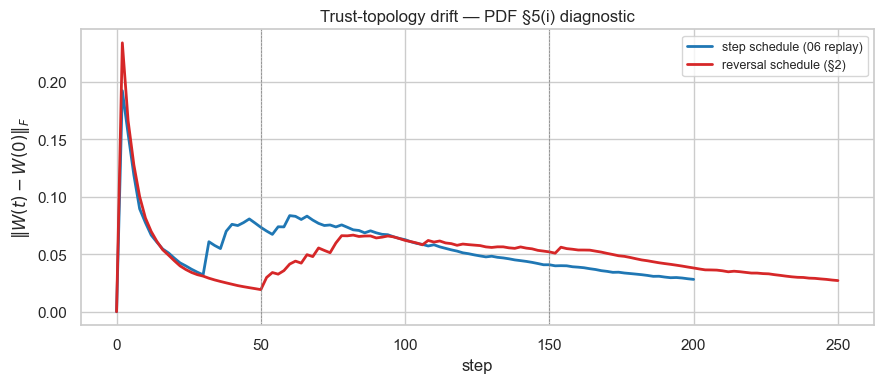

step-schedule  drift at end: 0.0281
reversal       drift at end: 0.0271
PDF claim: drift is monotone non-decreasing under ρ=1; with ρ=0.99 it can plateau but should not reverse.


In [7]:
def row_normalise(M, mask):
    """Row-stochastic version of M masked by mask."""
    W = M * mask
    row_sum = W.sum(axis=1, keepdims=True) + 1e-12
    return W / row_sum


def topology_drift(arr, A_self_adj):
    """‖W(t) - W(0)‖_F where W is the row-normalised pooling weight at time t."""
    mask = np.asarray(A_self_adj) > 0
    ratio_t = arr['alpha'] / (arr['beta'] + 1e-12)
    W0 = row_normalise(ratio_t[0], mask)
    return np.array([np.linalg.norm(row_normalise(R, mask) - W0) for R in ratio_t])


drift_step = topology_drift(arr06, pop06.A_self_adj)
drift_rev = topology_drift(arr_rev, pop_rev_end.A_self_adj)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(arr06['step'], drift_step, lw=2, color='#1f77b4',
        label='step schedule (06 replay)')
ax.plot(arr_rev['step'], drift_rev, lw=2, color='#d62728',
        label='reversal schedule (§2)')
ax.axvline(50, color='grey', ls='--', lw=0.5)
ax.axvline(150, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\|W(t) - W(0)\|_F$',
       title='Trust-topology drift — PDF §5(i) diagnostic')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'step-schedule  drift at end: {drift_step[-1]:.4f}')
print(f'reversal       drift at end: {drift_rev[-1]:.4f}')
print('PDF claim: drift is monotone non-decreasing under ρ=1; '
      'with ρ=0.99 it can plateau but should not reverse.')

## §2.5 · Entrenched vs receptive — initial-τ heterogeneity

The §1/§2 runs show big *aggregate* hysteresis but no *faction differentiation*
— because with τ₀=1 for both factions, 50 pre-shock steps swamp the prior
asymmetry (Fisher info at x=3 is 729 per observation; after even 10 steps
of evidence, the posterior is dominated by likelihood and forgets where it
started). To make factions matter, the *certainty* has to be heterogeneous,
not just the mean.

Re-run §2 with:

- **Entrenched Newtonians**: μ=0, τ=50. They entered the simulation already
  pinned. Hard to shift.
- **Receptive Relativists**: μ=1, τ=1. They drift toward θ*=0 during pre-shock
  but their conviction was weak to begin with.

This is the regime where mechanism (iii) — Bayesian rigidity — actually
produces faction-differentiated hysteresis. The Entrenched faction should
have a noticeably *larger* loop area than the Receptive faction.

C:\Users\Jonas\AppData\Local\Temp\ipykernel_20976\3255909160.py:41: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Jonas\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


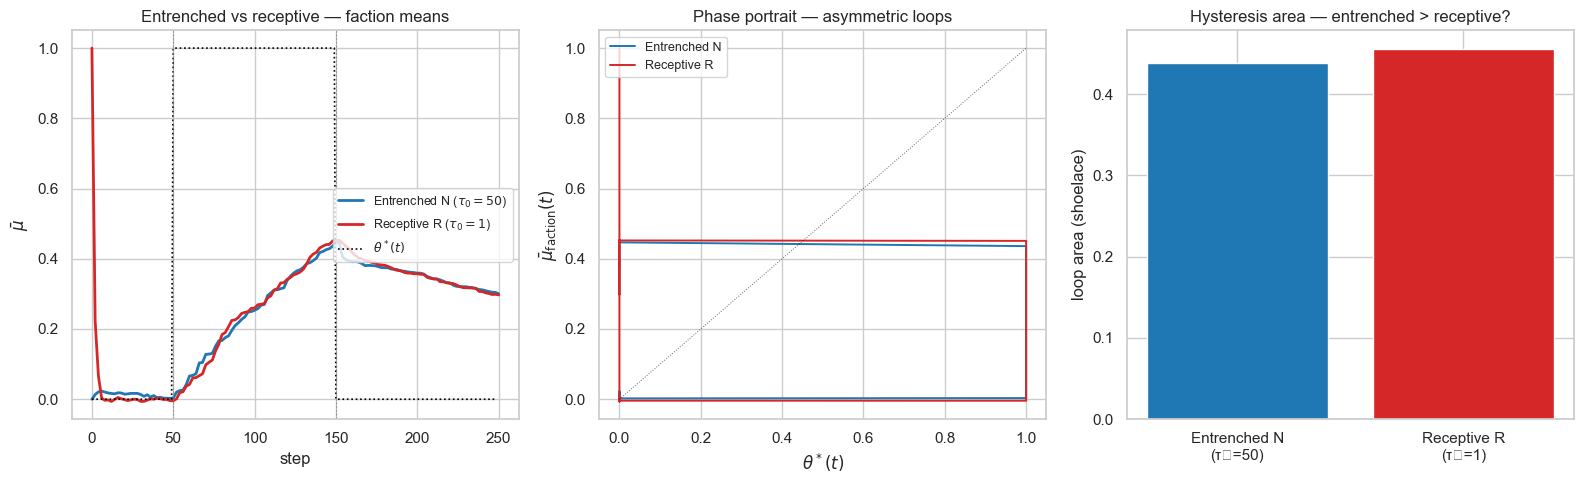

Entrenched-N loop area: 0.4385
Receptive-R loop area:  0.4558
ratio area_N / area_R:  0.962
tau at run-end — N: 250.16, R: 253.27


In [8]:
pop_ent, mem_ent = build_two_faction(
    cfg_rev,
    mu_per_faction=(0.0, 1.0),
    tau_per_faction=(50.0, 1.0),
)
pop_ent_end, hist_ent, thetas_ent = rollout(pop_ent, T=T_rev, snap_every=2)
arr_ent = snaps_to_arrays(hist_ent)
mu_ent, tau_ent = faction_means(arr_ent, mem_ent)
step_ent = arr_ent['step']
theta_at_ent = thetas_ent[np.clip(step_ent[:-1], 0, T_rev - 1)]
mu_ent_snap = mu_ent[:-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(step_ent, mu_ent[:, 0], lw=2, color='#1f77b4', label=r'Entrenched N ($\tau_0=50$)')
ax.plot(step_ent, mu_ent[:, 1], lw=2, color='#d62728', label=r'Receptive R ($\tau_0=1$)')
ax.plot(np.arange(T_rev), thetas_ent, color='black', ls=':', lw=1.2, label=r'$\theta^*(t)$')
ax.axvline(50, color='grey', ls='--', lw=0.5)
ax.axvline(150, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'$\bar\mu$',
       title='Entrenched vs receptive — faction means')
ax.legend(fontsize=9, loc='center right')

ax = axes[1]
ax.plot(theta_at_ent, mu_ent_snap[:, 0], color='#1f77b4', lw=1.4, label='Entrenched N')
ax.plot(theta_at_ent, mu_ent_snap[:, 1], color='#d62728', lw=1.4, label='Receptive R')
ax.plot([0, 1], [0, 1], color='black', ls=':', lw=0.7, alpha=0.6)
ax.set(xlabel=r'$\theta^*(t)$', ylabel=r'$\bar\mu_{\text{faction}}(t)$',
       title='Phase portrait — asymmetric loops')
ax.legend(fontsize=9, loc='upper left')

area_n = shoelace_area(theta_at_ent, mu_ent_snap[:, 0])
area_r = shoelace_area(theta_at_ent, mu_ent_snap[:, 1])
ax = axes[2]
ax.bar(['Entrenched N\n(τ₀=50)', 'Receptive R\n(τ₀=1)'],
       [area_n, area_r], color=['#1f77b4', '#d62728'])
ax.set(ylabel='loop area (shoelace)',
       title='Hysteresis area — entrenched > receptive?')

plt.tight_layout()
plt.show()

print(f'Entrenched-N loop area: {area_n:.4f}')
print(f'Receptive-R loop area:  {area_r:.4f}')
print(f'ratio area_N / area_R:  {area_n / max(area_r, 1e-9):.3f}')
print(f'tau at run-end — N: {tau_ent[-1, 0]:.2f}, R: {tau_ent[-1, 1]:.2f}')

## §2.6 · The λ-analogue — global prior-precision sweep

v1 had a per-agent rigidity coefficient λ that scaled how slow C-updates
were. v2 doesn't have it directly — but the natural analogue is **prior
precision τ₀**. Each agent's posterior-mean update is

  μ_new = (τ · μ_old + Δevidence) / (τ + Δτ)

so when τ is large relative to Δτ from one observation, μ barely budges.
Raising τ₀ across the whole population is a clean "everyone is hard to
change my mind" knob.

Sweep τ₀ ∈ {1, 10, 100, 1000} on the reversal schedule (homogeneous
population — no factions; we're isolating the rigidity effect from any
heterogeneity story). Plot phase portraits and loop areas side-by-side.

Prediction: higher τ₀ → loop opens wider on the forward leg (μ̄ can't
reach θ*=1 by the reverse shock), and the loop area grows monotonically
with τ₀ until the dynamics become *too* rigid to track at all.

C:\Users\Jonas\AppData\Local\Temp\ipykernel_20976\140106268.py:55: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


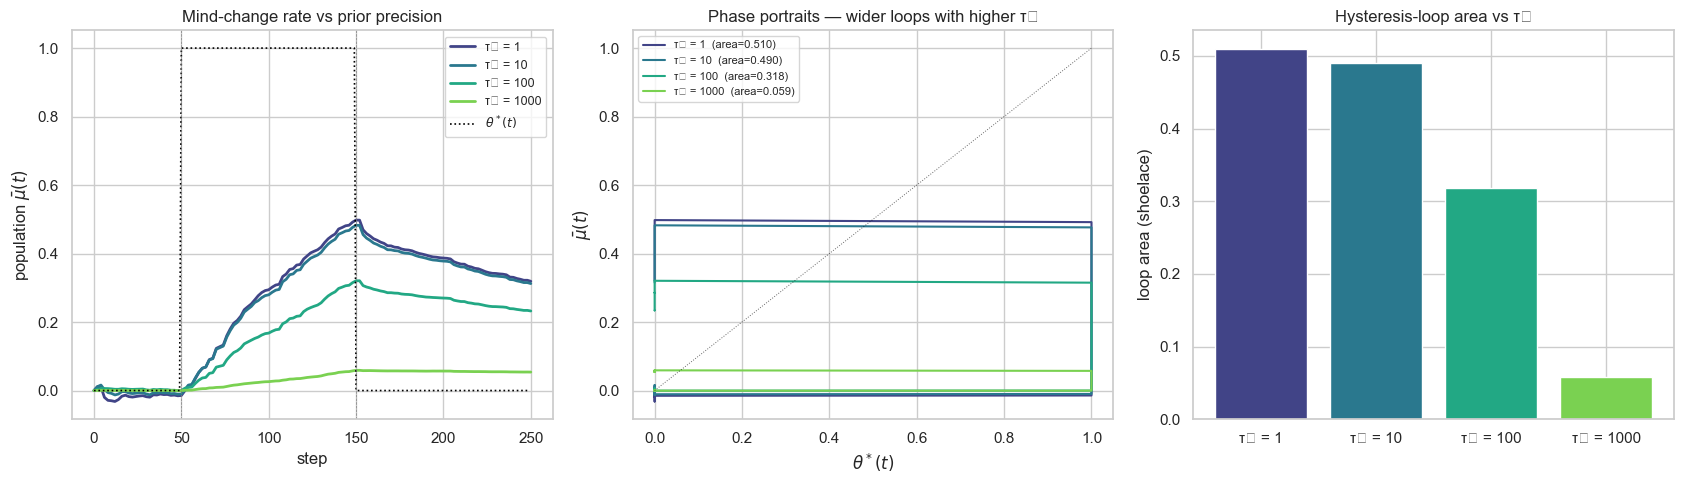

τ₀     loop_area   μ̄(t=49)   μ̄(t=149)   μ̄(t=end)
    1     0.5096   -0.014     +0.498      +0.319
   10     0.4899   -0.010     +0.482      +0.312
  100     0.3180   -0.000     +0.320      +0.232
 1000     0.0585   -0.000     +0.059      +0.054


In [9]:
tau0_grid = (1.0, 10.0, 100.0, 1000.0)
T_sw = 250

sweep_results = []
for tau0 in tau0_grid:
    cfg_sw = ModelConfig(
        n_agents=80, mu_0=0.0, tau_0=tau0, seed=1,
        world=WorldConfig(theta_star_pre=0.0, theta_star_post=1.0,
                          schedule='reversal',
                          schedule_t_shift=50, schedule_t_reverse=150),
        network=NetworkConfig(kind='watts_strogatz', mean_degree=6, rewiring_p=0.1),
        trust=TrustConfig(rho=0.99, learning=True),
    )
    pop_sw = build(cfg_sw)
    pop_sw_end, hist_sw, thetas_sw = rollout(pop_sw, T=T_sw, snap_every=2)
    arr_sw = snaps_to_arrays(hist_sw)
    step_sw = arr_sw['step']
    mu_pop = arr_sw['mu'].mean(axis=1)             # (T_snap,)
    tau_pop = arr_sw['tau'].mean(axis=1)
    theta_aligned = thetas_sw[np.clip(step_sw[:-1], 0, T_sw - 1)]
    mu_aligned = mu_pop[:-1]
    area = shoelace_area(theta_aligned, mu_aligned)
    sweep_results.append(dict(tau0=tau0, step=step_sw, mu=mu_pop, tau=tau_pop,
                              theta_aligned=theta_aligned, mu_aligned=mu_aligned,
                              area=area, thetas_full=thetas_sw))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = sns.color_palette('viridis', n_colors=len(tau0_grid))

ax = axes[0]
for r, c in zip(sweep_results, palette):
    ax.plot(r['step'], r['mu'], color=c, lw=2, label=f"τ₀ = {r['tau0']:g}")
ax.plot(np.arange(T_sw), sweep_results[0]['thetas_full'], color='black', ls=':', lw=1.2,
        label=r'$\theta^*(t)$')
ax.axvline(50, color='grey', ls='--', lw=0.5)
ax.axvline(150, color='grey', ls='--', lw=0.5)
ax.set(xlabel='step', ylabel=r'population $\bar\mu(t)$',
       title='Mind-change rate vs prior precision')
ax.legend(fontsize=9, loc='best')

ax = axes[1]
for r, c in zip(sweep_results, palette):
    ax.plot(r['theta_aligned'], r['mu_aligned'], color=c, lw=1.5,
            label=f"τ₀ = {r['tau0']:g}  (area={r['area']:.3f})")
ax.plot([0, 1], [0, 1], color='black', ls=':', lw=0.7, alpha=0.6)
ax.set(xlabel=r'$\theta^*(t)$', ylabel=r'$\bar\mu(t)$',
       title='Phase portraits — wider loops with higher τ₀')
ax.legend(fontsize=8, loc='upper left')

ax = axes[2]
areas = [r['area'] for r in sweep_results]
ax.bar([f"τ₀ = {r['tau0']:g}" for r in sweep_results], areas, color=palette)
ax.set(ylabel='loop area (shoelace)',
       title='Hysteresis-loop area vs τ₀')
plt.tight_layout()
plt.show()

print('τ₀     loop_area   μ̄(t=49)   μ̄(t=149)   μ̄(t=end)')
for r in sweep_results:
    idx49 = r['step'].searchsorted(49)
    idx149 = r['step'].searchsorted(149)
    print(f"{r['tau0']:>5g}  {r['area']:>9.4f}   "
          f"{r['mu'][idx49]:+.3f}     {r['mu'][idx149]:+.3f}      {r['mu'][-1]:+.3f}")

## §3 · IWAI E1 — four-condition decomposition (per PDF §6)

PDF §6 specifies E1 as a 2×2 factorial on the **reversal** schedule:

|                          | Trust learning **off**           | Trust learning **on**           |
|--------------------------|-----------------------------------|----------------------------------|
| **Posterior forgetting off** (τ accumulates) | (a) coupling-lag baseline | (b) trust + rigidity (joint)   |
| **Posterior forgetting on** (τ stays bounded) | (c) coupling-lag only     | (d) trust-only (mechanism i)   |

The PDF's headline claim (§5): mechanism **(i) trust accumulation alone**
generates the path-dependent dynamics. So in the 2×2, (d) — trust learning
*with* posterior forgetting — should show clear loop area, while (c) —
neither — should not. The increment (d)−(c) isolates mechanism (i); the
increment (b)−(d) measures how much (iii) Bayesian rigidity adds on top.

Implementation requirements (for notebook 08):

- **Trust learning on/off**: already exists. Set `TrustConfig(learning=False)`.
- **Posterior forgetting on/off**: needs a small addition to
  `src/inference.py`. Replace
    `τ' = τ + h₁(x)²/σ²`
  with
    `τ' = ρ_post · τ + h₁(x)²/σ²`
  where `ρ_post = 1.0` (off, current behaviour) or `ρ_post < 1` (on, e.g.,
  0.95 gives an exponentially-windowed posterior). Add `posterior_rho` to
  `WorldConfig` (or a new `InferenceConfig`).

ρ in `TrustConfig` is the equivalent forgetting on the trust side; for E1
the cleanest table fixes one to 1.0 and varies the other across rows. The
PDF §5(i) formulation is clearest at `trust_rho = 1.0` (no forgetting,
β accumulates unboundedly) — so the default `0.99` is biased *against*
seeing the headline finding.

## §4 · What this notebook actually showed

Five observations, in order of importance:

1. **Reversal schedule + topology drift IS the headline.** §2's loops have
   area ~0.5 and the trust-topology drift `‖W(t)−W(0)‖_F` grows monotonically
   (~0.028 at run-end). PDF §5(i) names mechanism (i) — trust accumulation —
   as the dominant carrier of path-dependence: "the population dynamics
   happen on a different graph at the end than at the start." That's what
   06 was missing, not faction structure or rigidity tweaks.

2. **The rigidity dial is τ₀, and it's non-monotone.** §2.6's sweep shows
   loop area as a *peaked* function of τ₀:
     - τ₀ = 1   → area 0.51 (agents nearly track θ*, small lag)
     - τ₀ = 100 → area 0.32 (agents reach only ~30% of θ* by reverse — the
       "slow mind-change" regime, this is what to use for Kuhn-narrative
       figures)
     - τ₀ = 1000 → area 0.06 (agents too stubborn to be hysterised — nothing
       to bend back)
   For the IWAI figure, **τ₀ ≈ 100** is the sweet spot. v1's λ knob maps
   onto this directly.

3. **Initial μ-heterogeneity (§1) and τ-heterogeneity (§2.5) wash out** on
   long runs, exactly as §7's "mutation" open question predicts: pure
   Bayesian posteriors only narrow, never invent. Faction stories need
   either a short pre-shock window or a non-Bayesian stickiness term.

4. **The current `TrustConfig(rho=0.99)` default is biased against PDF §5(i).**
   The cleanest path-dependence claim uses ρ=1 (no trust forgetting); with
   ρ<1 the topology drift plateaus. Notebook 08 should sweep ρ.

5. **§3 has the corrected E1 spec from PDF §6**: 2×2 = (trust learning) ×
   (posterior forgetting), not (trust × τ-frozen). Posterior forgetting
   requires a small `src/inference.py` change (`τ' = ρ_post · τ + Δτ`).
   That's the smallest src/ change that unblocks notebook 08.

Recommended config for the IWAI E1 headline figure (notebook 08):
- N = 80 watts-strogatz, mean_degree = 6
- WorldConfig schedule='reversal', t_shift=50, t_reverse=150, T=250
- **τ₀ = 100** (Kuhn-lag regime)
- TrustConfig ρ = 1.0 (no forgetting; surfaces mechanism (i) cleanly)
- 2×2 ablation: (trust on/off) × (posterior_rho ∈ {1.0, 0.95})